# Exploração e Preparação do MovieLens 1M

Este notebook documenta a seleção do dataset, a análise exploratória, as checagens de qualidade, a limpeza, a engenharia de atributos e a geração dos artefatos processados para os experimentos de recomendação.

In [31]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data.movielens_pipeline import (
    GLOBAL_SEED,
    build_feature_tables,
    clean_movielens_data,
    load_movielens_data,
    persist_processed_artifacts,
    profile_raw_data,
    temporal_leave_last_k_out,
)

RAW_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "movielens"
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)
GLOBAL_SEED

42

## Origem, licença, estrutura e justificativa

- **Dataset escolhido:** MovieLens 1M.
- **Origem:** GroupLens Research, University of Minnesota.
- **Documentação local:** `docs/DOCUMENTACAO - DATASET`.
- **Licença/uso:** permitido para pesquisa, com exigência de citação e restrição de redistribuição e uso comercial.
- **Estrutura:**
  - `ratings.dat`: `UserID::MovieID::Rating::Timestamp`
  - `users.dat`: `UserID::Gender::Age::Occupation::Zip-code`
  - `movies.dat`: `MovieID::Title::Genres`
- **Justificativa da escolha:** o dataset possui mais de 1 milhão de interações explícitas entre usuários e itens, atende ao mínimo de 10.000 interações, é amplamente usado em sistemas de recomendação e representa comportamento real de interação usuário-item, adequado para baselines e modelos neurais.

,metric,valor
0,interacoes,1.000209e+06
1,usuarios,6.040000e+03
2,itens_com_interacao,3.706000e+03
3,filmes_no_catalogo,3.883000e+03
4,media_interacoes_por_usuario,1.655975e+02
5,media_interacoes_por_item,2.698891e+02
6,esparsidade,9.553164e-01


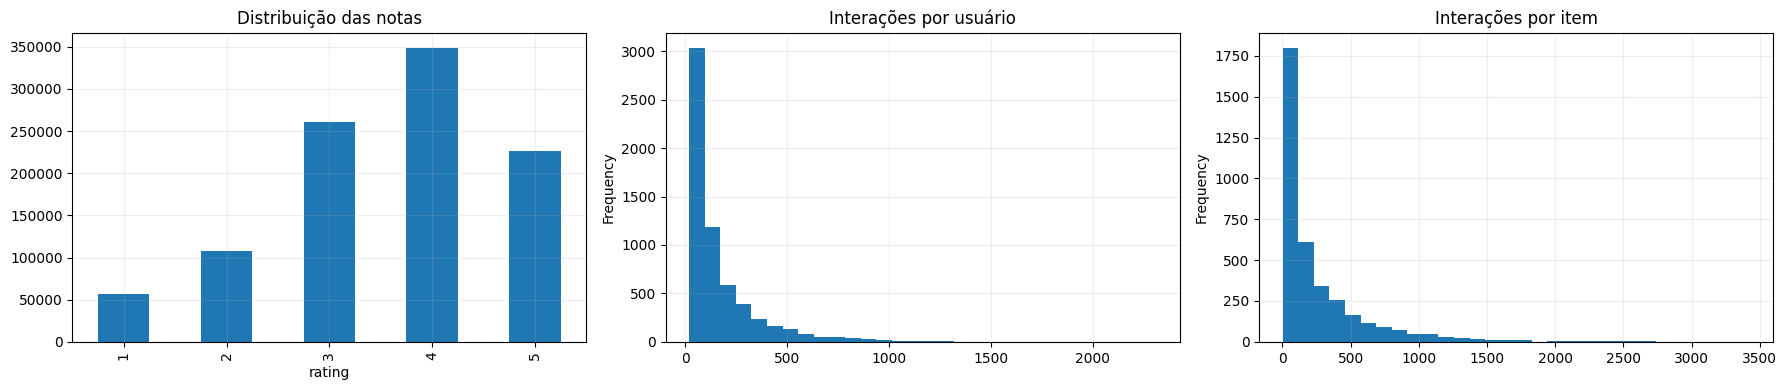

In [32]:
ratings = bundle.ratings.copy()
users = bundle.users.copy()
movies = bundle.movies.copy()

user_interactions = ratings.groupby("user_id").size()
item_interactions = ratings.groupby("movie_id").size()

eda_summary = pd.DataFrame(
    {
        "metric": [
            "interacoes",
            "usuarios",
            "itens_com_interacao",
            "filmes_no_catalogo",
            "media_interacoes_por_usuario",
            "media_interacoes_por_item",
            "esparsidade",
        ],
        "valor": [
            len(ratings),
            ratings["user_id"].nunique(),
            ratings["movie_id"].nunique(),
            movies["movie_id"].nunique(),
            user_interactions.mean(),
            item_interactions.mean(),
            raw_profile["summary"]["sparsity"],
        ],
    }
)
display(eda_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
ratings["rating"].value_counts().sort_index().plot(kind="bar", ax=axes[0], title="Distribuição das notas")
user_interactions.plot(kind="hist", bins=30, ax=axes[1], title="Interações por usuário")
item_interactions.plot(kind="hist", bins=30, ax=axes[2], title="Interações por item")
for ax in axes:
    ax.grid(alpha=0.2)
plt.tight_layout()

## Qualidade dos dados e limitações

- O conjunto bruto não apresenta valores ausentes nas colunas principais.
- Não há duplicidades completas nem referências inválidas entre `ratings`, `users` e `movies`.
- O dataset possui feedback explícito por notas, mas não contém contexto de sessão, impressões, cliques ou preço.
- Parte do catálogo não recebe interações; por isso a quantidade de filmes em `movies.dat` é maior que o número de itens presentes em `ratings.dat`.
- A documentação informa que há possíveis inconsistências manuais em filmes e dados demográficos voluntários nos usuários.

In [33]:
clean_bundle, quality_report = clean_movielens_data(bundle)
feature_tables = build_feature_tables(clean_bundle)
splits = temporal_leave_last_k_out(feature_tables["interactions"], validation_k=1, test_k=1)

artifact_summary = persist_processed_artifacts(
    feature_tables=feature_tables,
    splits=splits,
    output_dir=OUTPUT_DIR,
    quality_report={"raw_profile": raw_profile, "cleaning": quality_report},
    seed=GLOBAL_SEED,
)

split_summary = pd.DataFrame(
    {
        "split": ["train", "validation", "test"],
        "linhas": [len(splits["train"]), len(splits["validation"]), len(splits["test"])],
        "usuarios": [
            splits["train"]["user_id"].nunique(),
            splits["validation"]["user_id"].nunique(),
            splits["test"]["user_id"].nunique(),
        ],
    }
)

artifact_overview = pd.Series({key: value for key, value in artifact_summary.items() if not isinstance(value, (list, dict))}, name="valor").to_frame()
display(artifact_overview)
display(split_summary)

,valor
seed,42
n_interactions_full,1000209
n_train,988129
n_validation,6040
n_test,6040
n_users,6040
n_items,3706


,split,linhas,usuarios
0,train,988129,6040
1,validation,6040,6040
2,test,6040,6040


In [34]:
sanity_check = []
for user_id in feature_tables["interactions"]["user_id"].unique()[:5]:
    train_max = splits["train"].loc[splits["train"]["user_id"] == user_id, "timestamp"].max()
    validation_min = splits["validation"].loc[splits["validation"]["user_id"] == user_id, "timestamp"].min()
    test_min = splits["test"].loc[splits["test"]["user_id"] == user_id, "timestamp"].min()
    sanity_check.append(
        {
            "user_id": user_id,
            "train_max_timestamp": train_max,
            "validation_min_timestamp": validation_min,
            "test_min_timestamp": test_min,
            "sem_vazamento": bool(train_max < validation_min < test_min),
        }
    )

display(pd.DataFrame(sanity_check))
display(feature_tables["user_features"].head())
display(feature_tables["item_features"].head())
display(feature_tables["interactions"].head())

,user_id,train_max_timestamp,validation_min_timestamp,test_min_timestamp,sem_vazamento
0,1,978824330,978824330,978824351,False
1,2,978300174,978300174,978300174,False
2,3,978298486,978298486,978298504,False
3,4,978294282,978294282,978294282,False
4,5,978246576,978246576,978246585,False


,user_id,user_idx,age,occupation,zip_prefix,interaction_count,mean_rating,age_scaled,interaction_count_scaled,mean_rating_scaled,gender_F,gender_M
0,1,0,1,10,480,53,4.188679,0.000000,0.014385,0.803859,1.0,0.0
1,2,1,56,16,700,129,3.713178,1.000000,0.047515,0.683405,0.0,1.0
2,3,2,25,15,551,51,3.901961,0.436364,0.013514,0.731227,0.0,1.0
3,4,3,45,7,024,21,4.190476,0.800000,0.000436,0.804314,0.0,1.0
4,5,4,25,20,554,198,3.146465,0.436364,0.077594,0.539845,0.0,1.0


,movie_id,item_idx,title,release_year,interaction_count,mean_rating,release_year_scaled,interaction_count_scaled,mean_rating_scaled,genre_action,genre_adventure,genre_animation,genre_childrens,genre_comedy,genre_crime,genre_documentary,genre_drama,genre_fantasy,genre_film_noir,genre_horror,genre_musical,genre_mystery,genre_romance,genre_sci_fi,genre_thriller,genre_war,genre_western
0,1,0,Toy Story (1995),1995.0,2077,4.146846,0.938272,0.605778,0.786712,0,0,1,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2,1,Jumanji (1995),1995.0,701,3.201141,0.938272,0.204260,0.550285,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0
2,3,2,Grumpier Old Men (1995),1995.0,478,3.016736,0.938272,0.139189,0.504184,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
3,4,3,Waiting to Exhale (1995),1995.0,170,2.729412,0.938272,0.049314,0.432353,0,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0
4,5,4,Father of the Bride Part II (1995),1995.0,296,3.006757,0.938272,0.086081,0.501689,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0


,user_id,movie_id,rating,timestamp,rated_at,label,user_idx,item_idx
0,1,3186,4.0,978300019,2000-12-31 22:00:19+00:00,1,0,2969
1,1,1022,5.0,978300055,2000-12-31 22:00:55+00:00,1,0,957
2,1,1270,5.0,978300055,2000-12-31 22:00:55+00:00,1,0,1178
3,1,1721,4.0,978300055,2000-12-31 22:00:55+00:00,1,0,1574
4,1,2340,3.0,978300103,2000-12-31 22:01:43+00:00,1,0,2147


## Artefatos gerados

A execução persiste os seguintes arquivos em `data/processed/movielens`:

- `interactions_full.csv`
- `train_interactions.csv`
- `validation_interactions.csv`
- `test_interactions.csv`
- `user_features.csv`
- `item_features.csv`
- `metadata.json`

Esses artefatos já ficam no formato esperado para treinar baselines e também modelos neurais com embeddings de usuário e item, side features numéricas e atributos multi-hot de gênero.